В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



In [ ]:
https://github.com/ivashutych/Python-for-DS/blob/main/process_bank_churn.py

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from process_bank_churn import preprocess_data

In [3]:
preprocess_data

<function process_bank_churn.preprocess_data(raw_df: pandas.core.frame.DataFrame, scaler_numeric: bool = True) -> Tuple[pandas.core.frame.DataFrame, pandas.core.series.Series, pandas.core.frame.DataFrame, pandas.core.series.Series, List[str], Optional[sklearn.preprocessing._data.MinMaxScaler], sklearn.preprocessing._encoders.OneHotEncoder]>

In [4]:
raw_df = pd.read_csv('train.csv',  index_col=0, usecols = lambda x: x not in ['CustomerId', 'Surname'])

In [5]:
raw_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,
0,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [6]:
%load_ext autoreload
%autoreload 2

data = preprocess_data(raw_df)

In [7]:
X_train = data['train_X']
train_targets = data['train_y']
X_val = data['val_X']
val_targets = data['val_y']
input_cols =  data['input_cols']
scaler = data['scaler']
encoder = data['encoder']

In [8]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
id,,,,,,,,,,,,,
7180,0.599045,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0,0.0,1.0
10393,0.603819,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0,1.0,0.0
80,0.653938,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0,0.0,1.0
3365,0.568019,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0,0.0,1.0
12236,0.658711,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0,0.0,1.0


**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [9]:
model = DecisionTreeClassifier(random_state=42)

In [10]:
%%time
model.fit(X_train, train_targets)

CPU times: total: 46.9 ms
Wall time: 50.8 ms


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [11]:
train_probs = model.predict_proba(X_train)[:,1]
train_probs[:10]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [12]:
def predict_AUROC(targets,preds, name=''):
# Compute ROC curve
    fpr, tpr, thresholds = roc_curve(targets, preds, pos_label=1)

    # Compute AUROC
    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {roc_auc:.4f}')

In [13]:
predict_AUROC(train_targets,train_probs,'Train')

AUROC for Train: 1.0000


In [14]:
val_probs = model.predict_proba(X_val)[:,1]
val_probs

array([1., 0., 0., ..., 0., 0., 0.], shape=(3000,))

In [15]:
predict_AUROC(val_targets,val_probs, 'Validation')

AUROC for Validation: 0.7700


In [16]:
val_targets.value_counts() / len(val_targets)

Exited
0.0    0.796667
1.0    0.203333
Name: count, dtype: float64

Модель перетренерована. На валідаційних даних поганий результат, а на тренувальних 100%.

In [17]:
#Глибина дерева
model.tree_.max_depth

26

In [18]:
model_depth_2 = DecisionTreeClassifier(max_depth=2, random_state=42)

In [19]:
model_depth_2.fit(X_train, train_targets)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
tree_text = export_text(model_depth_2, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Age <= 0.46
|   |--- NumOfProducts <= 0.17
|   |   |--- class: 0.0
|   |--- NumOfProducts >  0.17
|   |   |--- class: 0.0
|--- Age >  0.46
|   |--- NumOfProducts <= 0.17
|   |   |--- class: 1.0
|   |--- NumOfProducts >  0.17
|   |   |--- class: 0.0



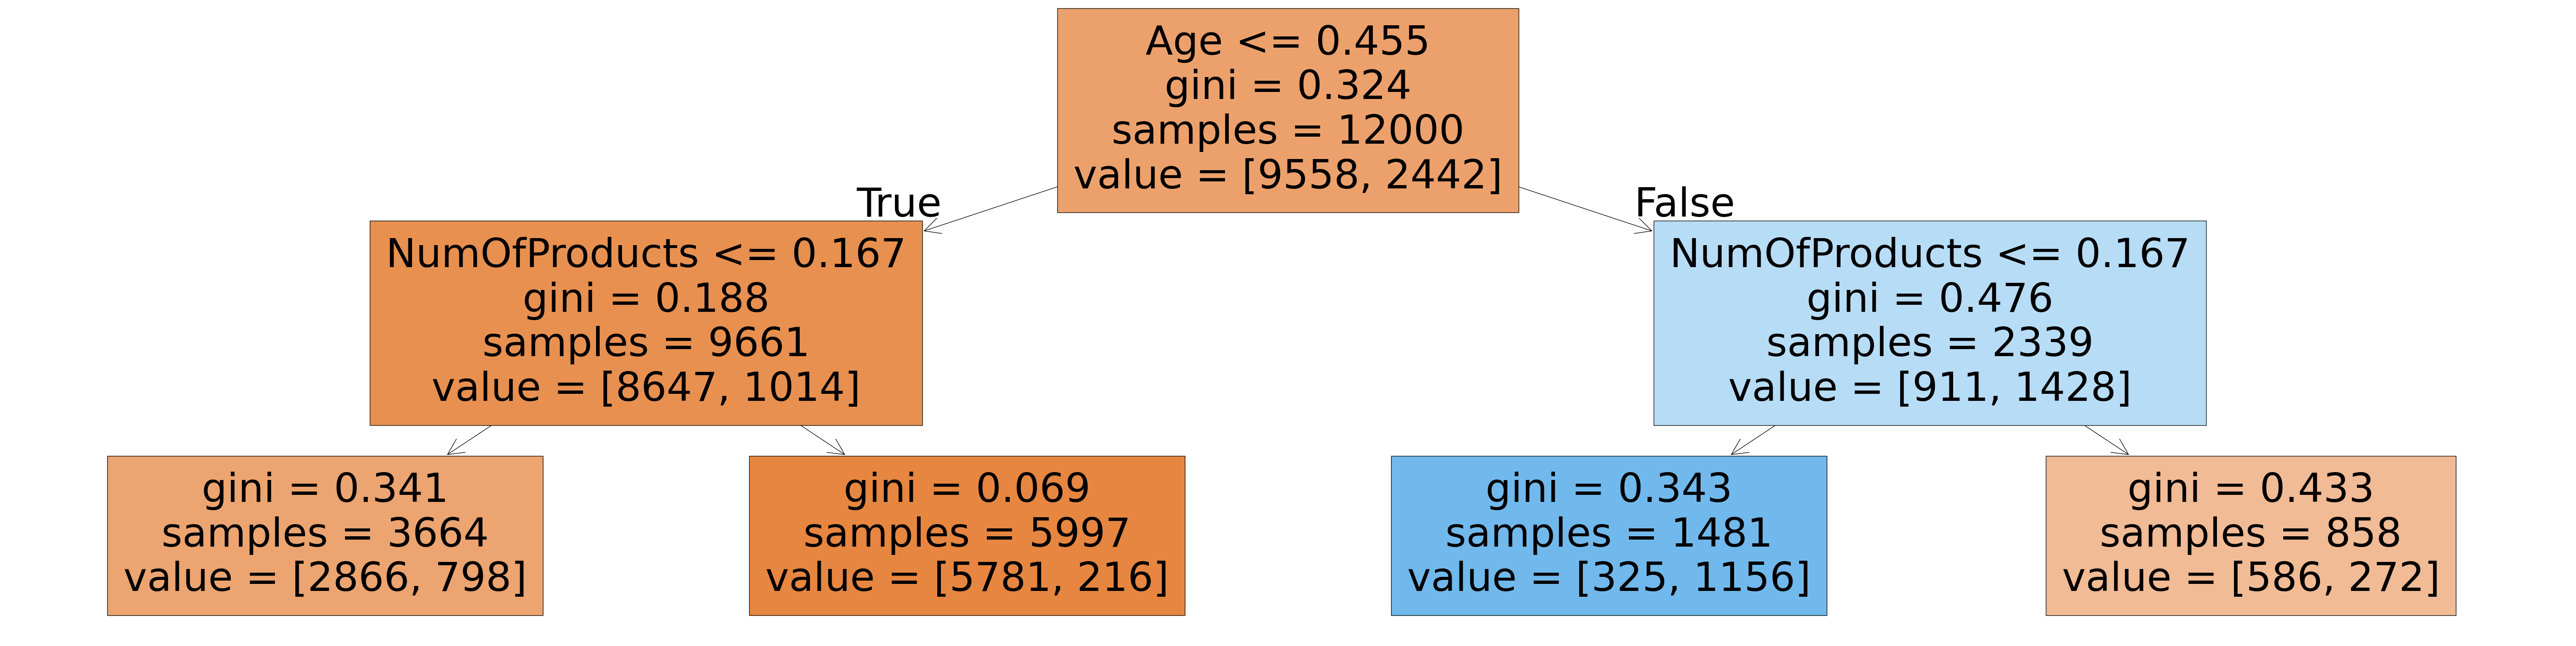

In [21]:
plt.figure(figsize=(80,20))
plot_tree(model_depth_2, feature_names=X_train.columns, filled=True);

Найвпливовішими є: Age і NumOfProducts.

In [22]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

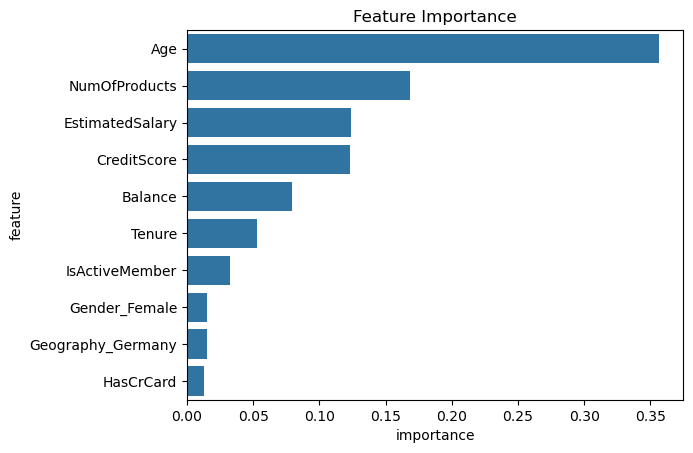

In [23]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [24]:
model_depth_test = DecisionTreeClassifier(max_depth=5, random_state=42)

In [25]:
model_depth_test.fit(X_train, train_targets)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
train_probs = model_depth_test.predict_proba(X_train)[:,1]
train_probs[:10]

array([0.04173355, 0.04173355, 0.11815562, 0.07417582, 0.00892374,
       0.23791103, 0.04173355, 0.72649573, 0.23791103, 0.27675277])

In [27]:
val_probs = model_depth_test.predict_proba(X_val)[:,1]
val_probs

array([1.        , 0.02761341, 0.02761341, ..., 0.00892374, 0.04173355,
       0.19251337], shape=(3000,))

In [28]:
predict_AUROC(train_targets,train_probs,'Train')
predict_AUROC(val_targets,val_probs,'Validation')

AUROC for Train: 0.9257
AUROC for Validation: 0.9219


Методом max_depth найкращий результат вийшов з max_depth=5.

In [29]:
model_leaf_test = DecisionTreeClassifier(max_leaf_nodes=38, random_state=42)

In [30]:
model_leaf_test.fit(X_train, train_targets)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,38
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
train_probs = model_leaf_test.predict_proba(X_train)[:,1]
train_probs[:10]

array([0.04173355, 0.04173355, 0.07090103, 0.07417582, 0.01437057,
       0.17120623, 0.04173355, 0.72649573, 0.17120623, 0.19090909])

In [32]:
val_probs = model_leaf_test.predict_proba(X_val)[:,1]
val_probs

array([1.        , 0.01437057, 0.01437057, ..., 0.01437057, 0.04173355,
       0.19251337], shape=(3000,))

In [33]:
predict_AUROC(train_targets,train_probs,'Train')
predict_AUROC(val_targets,val_probs,'Validation')

AUROC for Train: 0.9287
AUROC for Validation: 0.9244


Найкращі результати вийшла на max_leaf_nodes=38.

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [34]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, train_targets)
    train_error = 1 - model.score(X_train, train_targets)
    val_error = 1 - model.score(X_val, val_targets)
    train_probs = model.predict_proba(X_train)[:,1]
    val_probs = model.predict_proba(X_val)[:,1]

    # Compute ROC curve
    fpr_train, tpr_train, thresholds_train = roc_curve(train_targets, train_probs, pos_label=1)
    fpr_val, tpr_val, thresholds_val = roc_curve(val_targets, val_probs, pos_label=1)

    # Compute AUROC
    roc_auc_train = auc(fpr_train, tpr_train)
    roc_auc_val = auc(fpr_val, tpr_val)

    return {'Max Depth': md, 'Training Error': train_error, 'Validation Error': val_error, 'AUROC_train': roc_auc_train, 'AUROC_val': roc_auc_val}

In [35]:
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

In [36]:
errors_df.style.background_gradient(subset='Validation Error', cmap='Blues_r').background_gradient(subset='AUROC_val', cmap='Blues').format("{:.4f}")

,Max Depth,Training Error,Validation Error,AUROC_train,AUROC_val
0,1.0000,0.1604,0.1773,0.7447,0.7349
1,2.0000,0.1342,0.1390,0.8429,0.8465
2,3.0000,0.1185,0.1253,0.8972,0.8911
3,4.0000,0.1128,0.1180,0.9113,0.9113
4,5.0000,0.1048,0.1127,0.9257,0.9219
5,6.0000,0.0959,0.1090,0.9338,0.9211
6,7.0000,0.0923,0.1103,0.9415,0.9144
7,8.0000,0.0818,0.1093,0.9495,0.9031
8,9.0000,0.0737,0.1147,0.9591,0.8847
9,10.0000,0.0642,0.1173,0.9698,0.8484


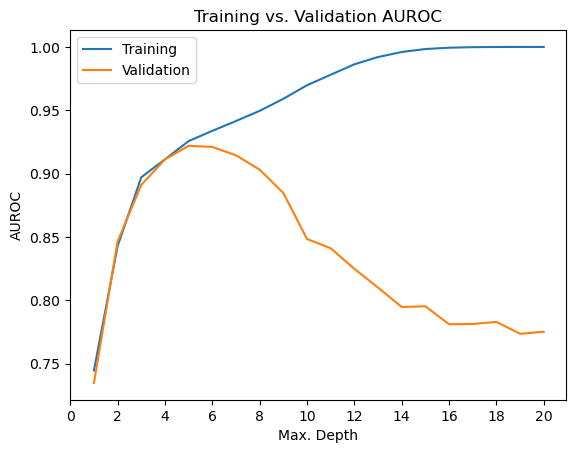

In [37]:
plt.figure()
plt.plot(errors_df['Max Depth'], errors_df['AUROC_train'])
plt.plot(errors_df['Max Depth'], errors_df['AUROC_val'])
plt.title('Training vs. Validation AUROC')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('AUROC')
plt.legend(['Training', 'Validation']);

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [38]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)

In [39]:
model.fit(X_train, train_targets)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [40]:
test_raw_df = pd.read_csv('test.csv', usecols = lambda x: x not in ['CustomerId', 'Surname'])

In [41]:
from process_bank_churn import preprocess_new_data

In [42]:
%load_ext autoreload
%autoreload 2

X_test, ids = preprocess_new_data(test_raw_df,input_cols,scaler,encoder)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
X_test.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,0.365155,0.214286,0.2,0.696265,0.000000,1.0,1.0,0.789477,0.0,1.0,0.0,0.0,1.0
1,0.286396,0.375000,0.5,0.000000,0.333333,1.0,1.0,0.337131,1.0,0.0,0.0,0.0,1.0
2,0.656325,0.446429,0.8,0.000000,0.333333,1.0,0.0,0.783859,1.0,0.0,0.0,0.0,1.0
3,0.682578,0.482143,0.3,0.000000,0.000000,1.0,1.0,0.834571,0.0,0.0,1.0,0.0,1.0
4,0.384248,0.446429,0.8,0.000000,0.333333,1.0,1.0,0.718421,0.0,0.0,1.0,0.0,1.0


In [44]:
preds = model.predict_proba(X_test)[:,1]

In [45]:
preds

array([0.23791103, 0.02761341, 0.02761341, ..., 0.00892374, 0.04173355,
       0.20459082], shape=(10000,))

In [46]:
sample_submission = pd.DataFrame({
    "id": ids,
    "Exited": preds
})

In [47]:
sample_submission

,id,Exited
0,15000,0.237911
1,15001,0.027613
2,15002,0.027613
3,15003,0.770925
4,15004,0.027613
...,...,...
9995,24995,0.027613
9996,24996,0.027613
9997,24997,0.008924
9998,24998,0.041734


In [48]:
sample_submission.to_csv('submission.csv',index=False)

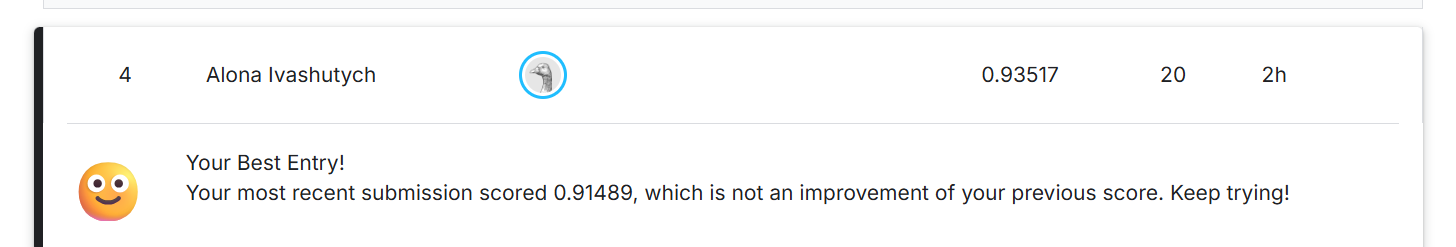